In [1]:
!pip install -q gradio transformers accelerate diffusers huggingface_hub

In [3]:
import gradio as gr
import torch
import transformers
import diffusers

print("✅ Gradio:", gr.__version__)
print("✅ Transformers:", transformers.__version__)
print("✅ Diffusers:", diffusers.__version__)
print("✅ CUDA:", torch.cuda.is_available())

✅ Gradio: 6.20.0
✅ Transformers: 5.13.1
✅ Diffusers: 0.39.0
✅ CUDA: True


In [4]:
import os
from huggingface_hub import snapshot_download

CATVTON_DIR = snapshot_download(
    repo_id="zhengchong/CatVTON",
    repo_type="model"
)

print("✅ CatVTON downloaded")
print("Path:", CATVTON_DIR)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

✅ CatVTON downloaded
Path: /root/.cache/huggingface/hub/models--zhengchong--CatVTON/snapshots/2969fcf85fe62f2036605716f0b56f0b81d01d79


In [5]:
print(os.listdir(CATVTON_DIR))

['flux-lora', 'config.json', 'SCHP', 'DensePose', 'mix-48k-1024', 'vitonhd-16k-512', 'dresscode-16k-512', 'README.md', '.gitattributes']


In [7]:
import os
import torch

# CatVTON repository root, NOT the mix-48k-1024 folder
CATVTON_CHECKPOINT = CATVTON_DIR

print("CatVTON checkpoint root:")
print(CATVTON_CHECKPOINT)

print("\nChecking required attention checkpoint:")
attention_path = os.path.join(
    CATVTON_CHECKPOINT,
    "mix-48k-1024",
    "attention"
)

print(attention_path)
print("Exists:", os.path.exists(attention_path))

if os.path.exists(attention_path):
    print("Files:", os.listdir(attention_path))

CatVTON checkpoint root:
/root/.cache/huggingface/hub/models--zhengchong--CatVTON/snapshots/2969fcf85fe62f2036605716f0b56f0b81d01d79

Checking required attention checkpoint:
/root/.cache/huggingface/hub/models--zhengchong--CatVTON/snapshots/2969fcf85fe62f2036605716f0b56f0b81d01d79/mix-48k-1024/attention
Exists: True
Files: ['model.safetensors']


In [8]:
from model.pipeline import CatVTONPipeline

BASE_MODEL = "booksforcharlie/stable-diffusion-inpainting"

pipe = CatVTONPipeline(
    base_ckpt=BASE_MODEL,
    attn_ckpt=CATVTON_DIR,
    attn_ckpt_version="mix",
    weight_dtype=torch.float16,
    device="cuda",
    compile=False,
    skip_safety_check=True,
    use_tf32=True,
)

print("✅ CatVTON pipeline loaded successfully")

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
An error occurred while trying to fetch booksforcharlie/stable-diffusion-inpainting: booksforcharlie/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
There are modules in UNet2DConditionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


✅ CatVTON pipeline loaded successfully


In [11]:
from google.colab import files

uploaded = files.upload()

Saving sample_files.zip to sample_files.zip


In [12]:
import zipfile
import os

zip_path = "/content/sample_files.zip"
extract_dir = "/content/sample_files"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ Extracted to:", extract_dir)

✅ Extracted to: /content/sample_files


In [13]:
import os

for root, dirs, files in os.walk("/content/sample_files"):
    for f in files:
        if f.startswith("person_01") or f.startswith("garment_01"):
            print(os.path.join(root, f))

/content/sample_files/sample_files/test_pairs/garment/garment_01.jpg
/content/sample_files/sample_files/test_pairs/person/person_01.png


In [15]:
import torch
from transformers import (
    AutoProcessor,
    AutoModelForZeroShotObjectDetection,
    SamProcessor,
    SamModel
)

device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# Grounding DINO
# ============================================================

DINO_MODEL = "IDEA-Research/grounding-dino-base"

print("Loading Grounding DINO...")

dino_processor = AutoProcessor.from_pretrained(DINO_MODEL)

dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    DINO_MODEL
)

dino_model.to(device)
dino_model.eval()

print("✅ Grounding DINO loaded")

# ============================================================
# SAM
# ============================================================

SAM_MODEL = "facebook/sam-vit-base"

print("\nLoading SAM...")

sam_processor = SamProcessor.from_pretrained(SAM_MODEL)

sam_model = SamModel.from_pretrained(SAM_MODEL)

sam_model.to(device)
sam_model.eval()

print("✅ SAM loaded")

print("\nDevice:", device)

Loading Grounding DINO...


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.74k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/6.57k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  375MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

✅ SAM loaded

Device: cuda


In [16]:
from PIL import Image
import torch

PERSON_PATH = "/content/sample_files/sample_files/test_pairs/person/person_01.png"

person = Image.open(PERSON_PATH).convert("RGB")

print("Person image:", person.size)

inputs = dino_processor(
    images=person,
    text="person.",
    return_tensors="pt"
)

inputs = {
    k: v.to(device) if hasattr(v, "to") else v
    for k, v in inputs.items()
}

with torch.no_grad():
    outputs = dino_model(**inputs)

results = dino_processor.post_process_grounded_object_detection(
    outputs,
    inputs["input_ids"],
    target_sizes=[person.size[::-1]]
)[0]

print("Detections:", len(results["boxes"]))

if len(results["boxes"]) > 0:
    best_idx = int(torch.argmax(results["scores"]))

    person_box = (
        results["boxes"][best_idx]
        .detach()
        .cpu()
        .tolist()
    )

    score = float(results["scores"][best_idx])

    print("✅ Person detected")
    print("Score:", round(score, 3))
    print("Box:", [round(x, 1) for x in person_box])
else:
    print("❌ No person detected")


Person image: (768, 1024)
Detections: 1
✅ Person detected
Score: 0.886
Box: [168.4, 14.5, 617.4, 1022.9]


✅ SAM person mask generated
Mask shape: (1024, 768)
Person pixels: 303091


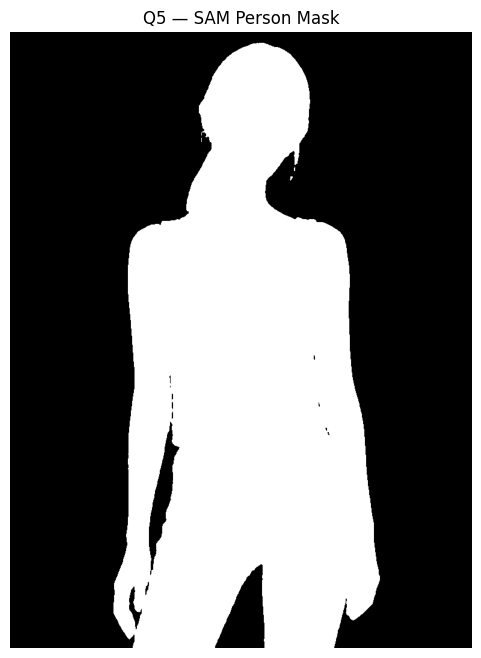

In [17]:
# ============================================================
# Q2 — Generate whole-person SAM mask
# ============================================================

sam_person_input = sam_processor(
    images=person,
    input_boxes=[[person_box]],
    return_tensors="pt"
)

sam_person_input = {
    k: v.to(device) if hasattr(v, "to") else v
    for k, v in sam_person_input.items()
}

with torch.no_grad():
    sam_person_output = sam_model(**sam_person_input)

person_masks_processed = sam_processor.image_processor.post_process_masks(
    sam_person_output.pred_masks.cpu(),
    sam_person_input["original_sizes"].cpu(),
    sam_person_input["reshaped_input_sizes"].cpu()
)

person_mask = person_masks_processed[0][0][0].numpy().astype(bool)

print("✅ SAM person mask generated")
print("Mask shape:", person_mask.shape)
print("Person pixels:", int(person_mask.sum()))

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 8))
plt.imshow(person_mask, cmap="gray")
plt.title("Q5 — SAM Person Mask")
plt.axis("off")
plt.show()

In [18]:
# ============================================================
# Q5 — Detect upper-body clothing with Grounding DINO
# ============================================================

text_prompt = (
    "shirt. t-shirt. t shirt. top. blouse. dress. jacket."
)

inputs = dino_processor(
    images=person,
    text=text_prompt,
    return_tensors="pt"
)

inputs = {
    k: v.to(device) if hasattr(v, "to") else v
    for k, v in inputs.items()
}

with torch.no_grad():
    outputs = dino_model(**inputs)

results = dino_processor.post_process_grounded_object_detection(
    outputs,
    inputs["input_ids"],
    target_sizes=[person.size[::-1]]
)[0]

detected_labels = results.get("text_labels", None)

if detected_labels is None:
    detected_labels = [
        str(x) for x in results.get("labels", [])
    ]

print("Detections:", len(results["boxes"]))

for i in range(len(results["boxes"])):
    print(
        f"{i}: "
        f"{detected_labels[i]} "
        f"score={float(results['scores'][i]):.3f} "
        f"box={[round(x, 1) for x in results['boxes'][i].cpu().tolist()]}"
    )

Detections: 2
0: dress score=0.269 box=[249.1, 304.5, 528.7, 699.5]
1: t - shirt t shirt score=0.328 box=[247.8, 303.1, 528.3, 698.5]


✅ Upper garment detected
Label: t - shirt t shirt
Score: 0.328
Box: [247.8, 303.1, 528.3, 698.5]
Clothing mask pixels: 78115
✅ Clothing mask saved:
/content/q5_outputs/person_01_clothing_mask.png


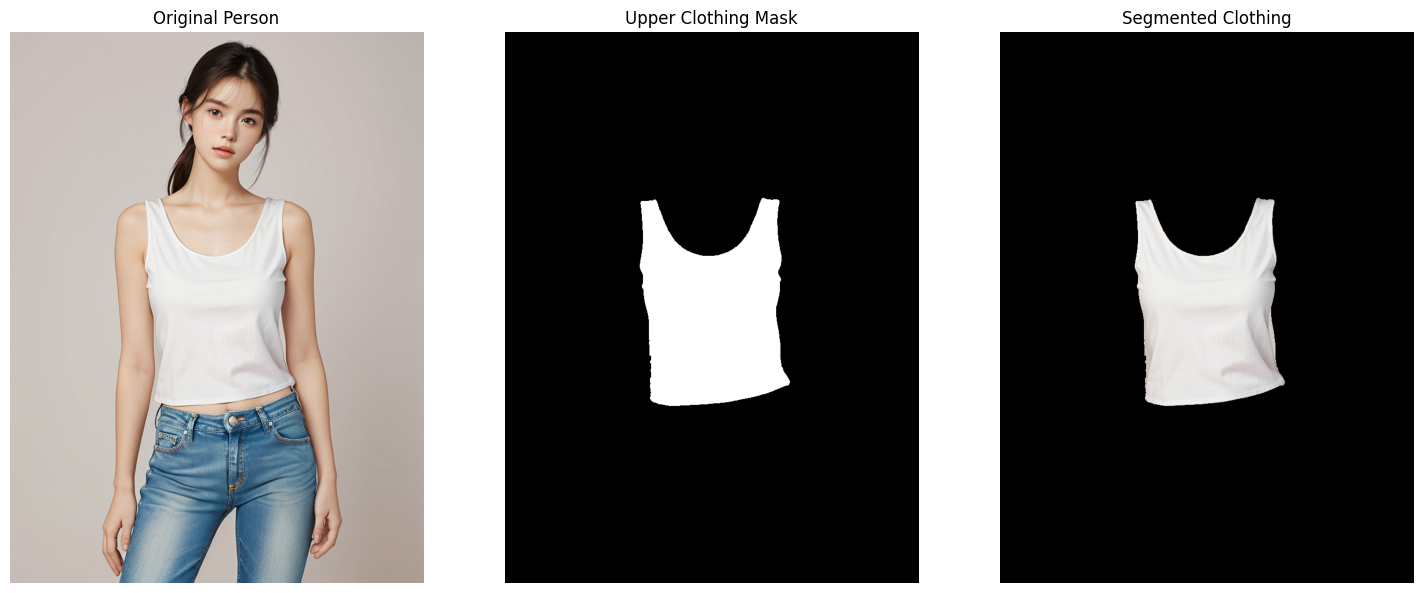

In [19]:
# ============================================================
# Q5 — Generate upper-clothing mask with SAM
# ============================================================

import numpy as np
from PIL import Image

# Possible upper-clothing labels
upper_labels = [
    "shirt", "t-shirt", "t shirt",
    "top", "blouse", "dress", "jacket"
]

candidate_indices = []

for i, label in enumerate(detected_labels):
    label_lower = str(label).lower().strip()

    if any(
        x == label_lower
        or x in label_lower
        or label_lower in x
        for x in upper_labels
    ):
        candidate_indices.append(i)

if not candidate_indices:
    print("❌ No upper-clothing detection found.")
else:
    # Select highest-confidence upper-clothing detection
    best_idx = max(
        candidate_indices,
        key=lambda i: float(results["scores"][i])
    )

    clothing_box = (
        results["boxes"][best_idx]
        .detach()
        .cpu()
        .tolist()
    )

    clothing_score = float(results["scores"][best_idx])
    clothing_label = str(detected_labels[best_idx])

    print("✅ Upper garment detected")
    print("Label:", clothing_label)
    print("Score:", round(clothing_score, 3))
    print(
        "Box:",
        [round(x, 1) for x in clothing_box]
    )

    # --------------------------------------------------------
    # SAM segmentation
    # --------------------------------------------------------

    sam_clothing_input = sam_processor(
        images=person,
        input_boxes=[[clothing_box]],
        return_tensors="pt"
    )

    sam_clothing_input = {
        k: v.to(device) if hasattr(v, "to") else v
        for k, v in sam_clothing_input.items()
    }

    with torch.no_grad():
        sam_clothing_output = sam_model(
            **sam_clothing_input
        )

    clothing_masks_processed = (
        sam_processor.image_processor.post_process_masks(
            sam_clothing_output.pred_masks.cpu(),
            sam_clothing_input["original_sizes"].cpu(),
            sam_clothing_input["reshaped_input_sizes"].cpu()
        )
    )

    clothing_mask = (
        clothing_masks_processed[0][0][0]
        .numpy()
        .astype(bool)
    )

    # Restrict clothing to detected person
    clothing_mask = clothing_mask & person_mask

    print(
        "Clothing mask pixels:",
        int(clothing_mask.sum())
    )

    # --------------------------------------------------------
    # Save mask
    # --------------------------------------------------------

    mask_output_dir = "/content/q5_outputs"
    os.makedirs(mask_output_dir, exist_ok=True)

    mask_path = os.path.join(
        mask_output_dir,
        "person_01_clothing_mask.png"
    )

    Image.fromarray(
        (clothing_mask * 255).astype(np.uint8)
    ).save(mask_path)

    print("✅ Clothing mask saved:")
    print(mask_path)

    # --------------------------------------------------------
    # Visualize
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1, 3,
        figsize=(15, 6)
    )

    axes[0].imshow(person)
    axes[0].set_title("Original Person")
    axes[0].axis("off")

    axes[1].imshow(clothing_mask, cmap="gray")
    axes[1].set_title("Upper Clothing Mask")
    axes[1].axis("off")

    masked = np.array(person).copy()
    masked[~clothing_mask] = [0, 0, 0]

    axes[2].imshow(masked)
    axes[2].set_title("Segmented Clothing")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

Person: (768, 1024)
Garment: (768, 1024)
Mask: (768, 1024)

🚀 Running CatVTON...


100%|██████████| 30/30 [00:07<00:00,  3.95it/s]



✅ CatVTON inference completed
✅ Output saved to:
/content/q5_outputs/pair_01_tryon.png


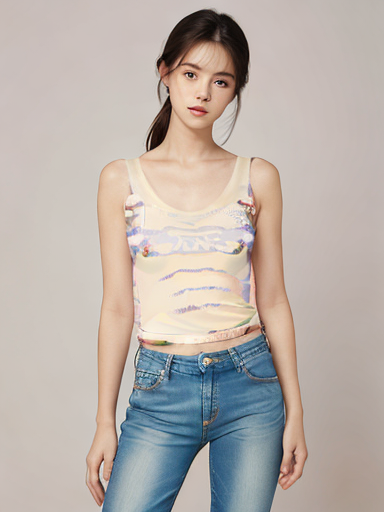

In [22]:
# ============================================================
# Q5 — CATVTON TEST WITH PERSON 01 + GARMENT 01
# ============================================================

import os
from PIL import Image

# ------------------------------------------------------------
# INPUT PATHS
# ------------------------------------------------------------

PERSON_PATH = (
    "/content/sample_files/sample_files/"
    "test_pairs/person/person_01.png"
)

GARMENT_PATH = (
    "/content/sample_files/sample_files/"
    "test_pairs/garment/garment_01.jpg"
)

MASK_PATH = (
    "/content/q5_outputs/"
    "person_01_clothing_mask.png"
)

OUTPUT_DIR = "/content/q5_outputs"
OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "pair_01_tryon.png"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# LOAD IMAGES
# ------------------------------------------------------------

person = Image.open(
    PERSON_PATH
).convert("RGB")

garment = Image.open(
    GARMENT_PATH
).convert("RGB")

mask = Image.open(
    MASK_PATH
).convert("L")

print("Person:", person.size)
print("Garment:", garment.size)
print("Mask:", mask.size)

# ------------------------------------------------------------
# RUN CATVTON
# ------------------------------------------------------------

print("\n🚀 Running CatVTON...")

result = pipe(
    image=person,
    condition_image=garment,
    mask=mask,
    num_inference_steps=30,
    guidance_scale=2.5,
    height=512,
    width=384,
)[0]

# ------------------------------------------------------------
# SAVE RESULT
# ------------------------------------------------------------

result.save(OUTPUT_PATH)

print("\n✅ CatVTON inference completed")
print("✅ Output saved to:")
print(OUTPUT_PATH)

# ------------------------------------------------------------
# DISPLAY RESULT
# ------------------------------------------------------------

display(result)

In [23]:
import gradio as gr
import time

def test_app(person_image, garment_image):
    if person_image is None:
        return None, "❌ Please upload a person image.", "—"

    if garment_image is None:
        return None, "❌ Please upload a garment image.", "—"

    start = time.time()

    # Temporary test output
    result = person_image

    elapsed = time.time() - start

    status = "✅ Images received successfully."

    processing_time = f"{elapsed:.2f} seconds"

    return result, status, processing_time


demo = gr.Interface(
    fn=test_app,
    inputs=[
        gr.Image(
            type="pil",
            label="Person Image"
        ),
        gr.Image(
            type="pil",
            label="Garment Image"
        )
    ],
    outputs=[
        gr.Image(
            label="Try-On Result"
        ),
        gr.Textbox(
            label="Status"
        ),
        gr.Textbox(
            label="Estimated Processing Time"
        )
    ],
    title="AI Virtual Try-On",
    description="Upload a person image and a garment image."
)

demo.launch(
    share=True,
    debug=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://5c4fed1371cb786eaf.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://5c4fed1371cb786eaf.gradio.live


In [24]:
demo.close()

Closing server running on port: 7860


In [25]:
import time
import gradio as gr
from PIL import Image

def run_tryon(person_image, garment_image):

    if person_image is None:
        return None, "❌ Please upload a person image.", "—"

    if garment_image is None:
        return None, "❌ Please upload a garment image.", "—"

    start_time = time.time()

    try:
        # ----------------------------------------------------
        # For this first integration test, use the
        # person_01 clothing mask we already generated.
        # ----------------------------------------------------

        mask_path = "/content/q5_outputs/person_01_clothing_mask.png"

        mask = Image.open(mask_path).convert("L")

        # ----------------------------------------------------
        # Run CatVTON
        # ----------------------------------------------------

        result = pipe(
            image=person_image.convert("RGB"),
            condition_image=garment_image.convert("RGB"),
            mask=mask,
            num_inference_steps=30,
            guidance_scale=2.5,
            height=512,
            width=384,
        )[0]

        elapsed = time.time() - start_time

        return (
            result,
            "✅ Try-on completed successfully.",
            f"{elapsed:.1f} seconds"
        )

    except Exception as e:

        elapsed = time.time() - start_time

        return (
            None,
            f"❌ Error: {str(e)}",
            f"{elapsed:.1f} seconds"
        )


demo = gr.Interface(
    fn=run_tryon,

    inputs=[
        gr.Image(
            type="pil",
            label="Person Image"
        ),
        gr.Image(
            type="pil",
            label="Garment Image"
        )
    ],

    outputs=[
        gr.Image(
            label="Try-On Result"
        ),
        gr.Textbox(
            label="Status"
        ),
        gr.Textbox(
            label="Processing Time"
        )
    ],

    title="AI Virtual Try-On",

    description=(
        "Upload a person image and a garment image "
        "to generate a virtual try-on result."
    )
)

demo.launch(
    share=True,
    debug=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d21ef4dfbcf1e63b72.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


100%|██████████| 30/30 [00:06<00:00,  4.31it/s]


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://d21ef4dfbcf1e63b72.gradio.live


In [30]:
# ============================================================
# Q5 — GENERATE CLOTHING MASKS FOR PERSON 02–05
# ============================================================

import os
import numpy as np
from PIL import Image

PERSON_DIR = "/content/sample_files/sample_files/test_pairs/person"
MASK_DIR = "/content/q5_outputs"

os.makedirs(MASK_DIR, exist_ok=True)

upper_labels = [
    "shirt",
    "t-shirt",
    "t shirt",
    "top",
    "blouse",
    "dress",
    "jacket"
]

for i in range(2, 6):

    print("\n" + "=" * 60)
    print(f"PROCESSING PERSON {i:02d}")

    # --------------------------------------------------------
    # Load person
    # --------------------------------------------------------

    person_path = os.path.join(
        PERSON_DIR,
        f"person_{i:02d}.png"
    )

    person = Image.open(
        person_path
    ).convert("RGB")

    print("Image:", person.size)

    # --------------------------------------------------------
    # Grounding DINO — detect person
    # --------------------------------------------------------

    person_inputs = dino_processor(
        images=person,
        text="person.",
        return_tensors="pt"
    )

    person_inputs = {
        k: v.to(device) if hasattr(v, "to") else v
        for k, v in person_inputs.items()
    }

    with torch.no_grad():
        person_outputs = dino_model(
            **person_inputs
        )

    person_results = (
        dino_processor
        .post_process_grounded_object_detection(
            person_outputs,
            person_inputs["input_ids"],
            target_sizes=[person.size[::-1]]
        )[0]
    )

    if len(person_results["boxes"]) == 0:
        print("❌ No person detected")
        continue

    best_person_idx = int(
        torch.argmax(person_results["scores"])
    )

    person_box = (
        person_results["boxes"][best_person_idx]
        .detach()
        .cpu()
        .tolist()
    )

    print(
        "✅ Person detected:",
        [round(x, 1) for x in person_box]
    )

    # --------------------------------------------------------
    # SAM — whole person
    # --------------------------------------------------------

    sam_person_input = sam_processor(
        images=person,
        input_boxes=[[person_box]],
        return_tensors="pt"
    )

    sam_person_input = {
        k: v.to(device) if hasattr(v, "to") else v
        for k, v in sam_person_input.items()
    }

    with torch.no_grad():
        sam_person_output = sam_model(
            **sam_person_input
        )

    person_masks = (
        sam_processor.image_processor.post_process_masks(
            sam_person_output.pred_masks.cpu(),
            sam_person_input["original_sizes"].cpu(),
            sam_person_input["reshaped_input_sizes"].cpu()
        )
    )

    person_mask = (
        person_masks[0][0][0]
        .numpy()
        .astype(bool)
    )

    # --------------------------------------------------------
    # Grounding DINO — upper clothing
    # --------------------------------------------------------

    clothing_prompt = (
        "shirt. t-shirt. t shirt. top. "
        "blouse. dress. jacket."
    )

    clothing_inputs = dino_processor(
        images=person,
        text=clothing_prompt,
        return_tensors="pt"
    )

    clothing_inputs = {
        k: v.to(device) if hasattr(v, "to") else v
        for k, v in clothing_inputs.items()
    }

    with torch.no_grad():
        clothing_outputs = dino_model(
            **clothing_inputs
        )

    clothing_results = (
        dino_processor
        .post_process_grounded_object_detection(
            clothing_outputs,
            clothing_inputs["input_ids"],
            target_sizes=[person.size[::-1]]
        )[0]
    )

    labels = clothing_results.get(
        "text_labels",
        None
    )

    if labels is None:
        labels = [
            str(x)
            for x in clothing_results.get(
                "labels",
                []
            )
        ]

    candidate_indices = []

    for j, label in enumerate(labels):

        label_lower = str(label).lower().strip()

        if any(
            candidate == label_lower
            or candidate in label_lower
            or label_lower in candidate
            for candidate in upper_labels
        ):
            candidate_indices.append(j)

    if not candidate_indices:
        print("❌ No upper clothing detected")
        continue

    # Highest confidence clothing detection
    best_idx = max(
        candidate_indices,
        key=lambda j: float(
            clothing_results["scores"][j]
        )
    )

    clothing_box = (
        clothing_results["boxes"][best_idx]
        .detach()
        .cpu()
        .tolist()
    )

    print(
        "✅ Clothing:",
        labels[best_idx],
        "score=",
        round(
            float(
                clothing_results["scores"][best_idx]
            ),
            3
        )
    )

    # --------------------------------------------------------
    # SAM — clothing
    # --------------------------------------------------------

    sam_clothing_input = sam_processor(
        images=person,
        input_boxes=[[clothing_box]],
        return_tensors="pt"
    )

    sam_clothing_input = {
        k: v.to(device) if hasattr(v, "to") else v
        for k, v in sam_clothing_input.items()
    }

    with torch.no_grad():
        sam_clothing_output = sam_model(
            **sam_clothing_input
        )

    clothing_masks = (
        sam_processor.image_processor.post_process_masks(
            sam_clothing_output.pred_masks.cpu(),
            sam_clothing_input["original_sizes"].cpu(),
            sam_clothing_input["reshaped_input_sizes"].cpu()
        )
    )

    clothing_mask = (
        clothing_masks[0][0][0]
        .numpy()
        .astype(bool)
    )

    # Restrict clothing to actual person
    clothing_mask = clothing_mask & person_mask

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    output_path = os.path.join(
        MASK_DIR,
        f"person_{i:02d}_clothing_mask.png"
    )

    Image.fromarray(
        (clothing_mask * 255).astype(np.uint8)
    ).save(output_path)

    print("✅ Saved:", output_path)

print("\n" + "=" * 60)
print("MASK GENERATION COMPLETE")
print("=" * 60)


PROCESSING PERSON 02
Image: (768, 1024)
✅ Person detected: [166.4, -0.2, 589.8, 1021.9]
✅ Clothing: t - shirt t shirt score= 0.398
✅ Saved: /content/q5_outputs/person_02_clothing_mask.png

PROCESSING PERSON 03
Image: (768, 1024)
✅ Person detected: [172.5, 11.9, 605.3, 1021.7]
✅ Clothing: t - shirt t shirt score= 0.36
✅ Saved: /content/q5_outputs/person_03_clothing_mask.png

PROCESSING PERSON 04
Image: (768, 1024)
✅ Person detected: [131.3, 1.2, 583.2, 1021.4]
✅ Clothing: dress score= 0.41
✅ Saved: /content/q5_outputs/person_04_clothing_mask.png

PROCESSING PERSON 05
Image: (768, 1024)
✅ Person detected: [175.8, 6.5, 618.1, 1021.5]
✅ Clothing: t - shirt t shirt score= 0.424
✅ Saved: /content/q5_outputs/person_05_clothing_mask.png

MASK GENERATION COMPLETE


In [31]:
import os
from PIL import Image

PERSON_DIR = "/content/sample_files/sample_files/test_pairs/person"
GARMENT_DIR = "/content/sample_files/sample_files/test_pairs/garment"
MASK_DIR = "/content/q5_outputs"
OUTPUT_DIR = "/content/q5_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

for i in range(1, 6):

    output_path = os.path.join(
        OUTPUT_DIR,
        f"pair_{i:02d}_tryon.png"
    )

    if os.path.exists(output_path):
        print(f"✅ Pair {i:02d} already exists")
        continue

    person_path = os.path.join(
        PERSON_DIR,
        f"person_{i:02d}.png"
    )

    garment_path = os.path.join(
        GARMENT_DIR,
        f"garment_{i:02d}.jpg"
    )

    mask_path = os.path.join(
        MASK_DIR,
        f"person_{i:02d}_clothing_mask.png"
    )

    person = Image.open(person_path).convert("RGB")
    garment = Image.open(garment_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    print("\n" + "=" * 60)
    print(f"🚀 RUNNING CATVTON — PAIR {i:02d}")

    result = pipe(
        image=person,
        condition_image=garment,
        mask=mask,
        num_inference_steps=30,
        guidance_scale=2.5,
        height=512,
        width=384,
    )[0]

    result.save(output_path)

    print(f"✅ Pair {i:02d} completed")
    print(f"Saved: {output_path}")

print("\n" + "=" * 60)
print("FINAL OUTPUT CHECK")
print("=" * 60)

for i in range(1, 6):
    path = os.path.join(
        OUTPUT_DIR,
        f"pair_{i:02d}_tryon.png"
    )

    print(
        f"pair_{i:02d}:",
        "✅" if os.path.exists(path) else "❌"
    )

✅ Pair 01 already exists

🚀 RUNNING CATVTON — PAIR 02


100%|██████████| 30/30 [00:07<00:00,  4.04it/s]


✅ Pair 02 completed
Saved: /content/q5_outputs/pair_02_tryon.png

🚀 RUNNING CATVTON — PAIR 03


100%|██████████| 30/30 [00:07<00:00,  4.11it/s]


✅ Pair 03 completed
Saved: /content/q5_outputs/pair_03_tryon.png

🚀 RUNNING CATVTON — PAIR 04


100%|██████████| 30/30 [00:07<00:00,  3.96it/s]


✅ Pair 04 completed
Saved: /content/q5_outputs/pair_04_tryon.png

🚀 RUNNING CATVTON — PAIR 05


100%|██████████| 30/30 [00:07<00:00,  3.87it/s]


✅ Pair 05 completed
Saved: /content/q5_outputs/pair_05_tryon.png

FINAL OUTPUT CHECK
pair_01: ✅
pair_02: ✅
pair_03: ✅
pair_04: ✅
pair_05: ✅


In [32]:
import torch
import torch.nn.functional as F
from transformers import AutoImageProcessor, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"

DINO_MODEL = "facebook/dinov2-base"

print("Loading DINOv2...")

processor = AutoImageProcessor.from_pretrained(DINO_MODEL)

dinov2 = AutoModel.from_pretrained(
    DINO_MODEL
).to(device)

dinov2.eval()

print("✅ DINOv2 loaded")
print("Device:", device)

Loading DINOv2...


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

✅ DINOv2 loaded
Device: cuda


In [33]:
import torch
import torch.nn.functional as F
from PIL import Image
import os

PERSON_DIR = "/content/sample_files/sample_files/test_pairs/person"
GARMENT_DIR = "/content/sample_files/sample_files/test_pairs/garment"
RESULT_DIR = "/content/q5_outputs"

def get_embedding(image):
    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = dinov2(**inputs)

    embedding = outputs.last_hidden_state[:, 0, :]
    embedding = F.normalize(
        embedding,
        p=2,
        dim=1
    )

    return embedding


def get_upper_body_crop(image):
    width, height = image.size

    left = int(width * 0.15)
    right = int(width * 0.85)
    top = int(height * 0.20)
    bottom = int(height * 0.75)

    return image.crop(
        (left, top, right, bottom)
    )


garment_fidelity_results = []

for i in range(1, 6):

    result_path = os.path.join(
        RESULT_DIR,
        f"pair_{i:02d}_tryon.png"
    )

    garment_path = os.path.join(
        GARMENT_DIR,
        f"garment_{i:02d}.jpg"
    )

    output_image = Image.open(
        result_path
    ).convert("RGB")

    garment_image = Image.open(
        garment_path
    ).convert("RGB")

    # Approximate garment region in generated image
    garment_region = get_upper_body_crop(
        output_image
    )

    generated_embedding = get_embedding(
        garment_region
    )

    original_embedding = get_embedding(
        garment_image
    )

    score = F.cosine_similarity(
        generated_embedding,
        original_embedding
    ).item()

    garment_fidelity_results.append({
        "pair_id": f"pair_{i:02d}",
        "garment_fidelity_score": round(score, 4)
    })

    print(
        f"pair_{i:02d}: "
        f"garment fidelity = {score:.4f}"
    )

print("\n✅ GARMENT FIDELITY COMPLETE")

pair_01: garment fidelity = 0.2103
pair_02: garment fidelity = 0.2893
pair_03: garment fidelity = 0.3694
pair_04: garment fidelity = 0.3648
pair_05: garment fidelity = 0.3800

✅ GARMENT FIDELITY COMPLETE


In [35]:
!pip install -q insightface onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.8/249.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 38.8 MB/s eta 0:00:00


In [36]:
from insightface.app import FaceAnalysis

face_app = FaceAnalysis(
    name="buffalo_l",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

face_app.prepare(
    ctx_id=0,
    det_size=(640, 640)
)

print("✅ InsightFace loaded")

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:05<00:00, 48839.35KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
✅ InsightFac

In [37]:
from insightface.app import FaceAnalysis

face_app = FaceAnalysis(
    name="buffalo_l",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

face_app.prepare(
    ctx_id=0,
    det_size=(640, 640)
)

print("✅ InsightFace loaded")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
✅ InsightFac

In [38]:
import cv2
import numpy as np
import os

def get_face_embedding(image_path):
    img = cv2.imread(image_path)

    if img is None:
        return None

    faces = face_app.get(img)

    if len(faces) == 0:
        return None

    # Largest detected face
    face = max(
        faces,
        key=lambda f:
        (f.bbox[2] - f.bbox[0]) *
        (f.bbox[3] - f.bbox[1])
    )

    embedding = face.embedding.astype(np.float32)

    # Normalize
    norm = np.linalg.norm(embedding)

    if norm == 0:
        return None

    return embedding / norm


identity_results = []

PERSON_DIR = "/content/sample_files/sample_files/test_pairs/person"
RESULT_DIR = "/content/q5_outputs"

for i in range(1, 6):

    person_path = os.path.join(
        PERSON_DIR,
        f"person_{i:02d}.png"
    )

    tryon_path = os.path.join(
        RESULT_DIR,
        f"pair_{i:02d}_tryon.png"
    )

    original_embedding = get_face_embedding(
        person_path
    )

    tryon_embedding = get_face_embedding(
        tryon_path
    )

    if original_embedding is None:
        print(
            f"pair_{i:02d}: ❌ "
            "No face detected in original"
        )
        continue

    if tryon_embedding is None:
        print(
            f"pair_{i:02d}: ❌ "
            "No face detected in try-on output"
        )
        continue

    score = float(
        np.dot(
            original_embedding,
            tryon_embedding
        )
    )

    identity_results.append({
        "pair_id": f"pair_{i:02d}",
        "identity_preservation_score": round(
            score, 4
        )
    })

    print(
        f"pair_{i:02d}: "
        f"identity preservation = {score:.4f}"
    )

print("\n✅ IDENTITY PRESERVATION COMPLETE")

pair_01: identity preservation = 0.4779
pair_02: identity preservation = 0.5518
pair_03: identity preservation = 0.5661
pair_04: identity preservation = 0.6556
pair_05: identity preservation = 0.4533

✅ IDENTITY PRESERVATION COMPLETE


In [49]:
import os

Q5_DIR = "/content/q5_outputs"

print("=" * 60)
print("Q5 DEMO ASSETS")
print("=" * 60)

for i in range(1, 6):
    print(f"\nPair {i:02d}")

    files = [
        f"person_{i:02d}_clothing_mask.png",
        f"pair_{i:02d}_tryon.png",
    ]

    for file in files:
        path = os.path.join(Q5_DIR, file)
        print(
            f"  {file}:",
            "✅ FOUND" if os.path.exists(path) else "❌ MISSING"
        )

Q5 DEMO ASSETS

Pair 01
  person_01_clothing_mask.png: ✅ FOUND
  pair_01_tryon.png: ✅ FOUND

Pair 02
  person_02_clothing_mask.png: ✅ FOUND
  pair_02_tryon.png: ✅ FOUND

Pair 03
  person_03_clothing_mask.png: ✅ FOUND
  pair_03_tryon.png: ✅ FOUND

Pair 04
  person_04_clothing_mask.png: ✅ FOUND
  pair_04_tryon.png: ✅ FOUND

Pair 05
  person_05_clothing_mask.png: ✅ FOUND
  pair_05_tryon.png: ✅ FOUND


In [50]:
import gradio as gr
import os
from PIL import Image

Q5_DIR = "/content/q5_outputs"
PERSON_DIR = "/content/sample_files/sample_files/test_pairs/person"
GARMENT_DIR = "/content/sample_files/sample_files/test_pairs/garment"


def load_pair(pair_id):
    i = int(pair_id)

    person_path = os.path.join(
        PERSON_DIR,
        f"person_{i:02d}.png"
    )

    garment_path = os.path.join(
        GARMENT_DIR,
        f"garment_{i:02d}.jpg"
    )

    tryon_path = os.path.join(
        Q5_DIR,
        f"pair_{i:02d}_tryon.png"
    )

    mask_path = os.path.join(
        Q5_DIR,
        f"person_{i:02d}_clothing_mask.png"
    )

    person = Image.open(person_path).convert("RGB")
    garment = Image.open(garment_path).convert("RGB")
    tryon = Image.open(tryon_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    return person, garment, mask, tryon


with gr.Blocks(title="Virtual Try-On Demo") as demo:

    gr.Markdown(
        """
        # 👕 AI Virtual Try-On Demo

        **CatVTON-based virtual try-on pipeline**

        Select a test pair to view the person, garment,
        clothing mask, and generated virtual try-on result.
        """
    )

    pair_selector = gr.Dropdown(
        choices=["1", "2", "3", "4", "5"],
        value="1",
        label="Select Test Pair"
    )

    run_button = gr.Button(
        "Generate Try-On",
        variant="primary"
    )

    with gr.Row():

        person_output = gr.Image(
            label="Person Image",
            type="pil"
        )

        garment_output = gr.Image(
            label="Garment Image",
            type="pil"
        )

    with gr.Row():

        mask_output = gr.Image(
            label="Clothing Mask",
            type="pil"
        )

        tryon_output = gr.Image(
            label="Virtual Try-On Result",
            type="pil"
        )

    run_button.click(
        fn=load_pair,
        inputs=pair_selector,
        outputs=[
            person_output,
            garment_output,
            mask_output,
            tryon_output
        ]
    )

    gr.Markdown(
        """
        ### Evaluation

        - **Garment Fidelity:** Measures how well the generated output preserves the target garment.
        - **Identity Preservation:** Measures how well the person's identity is maintained.
        """
    )


demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a8f2dd70f1c505597e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
